---
title: "Fase 3: Agrupamiento (Clustering)"
subtitle: "Proyecto Final - Almacenes y Minería de Datos"
author: "Daniela Alejandra Sanluis Castillo"
date: "2026-06-03"
---


### Paso 1: Selección de Variables, Preprocesamiento y Método del Codo

Como el algoritmo K-Means mide la distancia geométrica entre los puntos, fue obligatorio aplicar una estandarización (`StandardScaler`). Esto equilibra los datos para que la escala de los años en la edad no aplaste ni domine por completo a las variables de las enfermedades. Luego, se calculó la "inercia" (qué tan separados quedan los grupos por dentro) probando desde 1 hasta 6 grupos posibles.

**Variables analizadas:**
* `EDAD` (Escala numérica continua).
* `DIABETES`, `HIPERTENSION`, `OBESIDAD` (Variables categóricas transformadas a valores numéricos de $1 = \text{SÍ}$ y $0 = \text{NO}$).

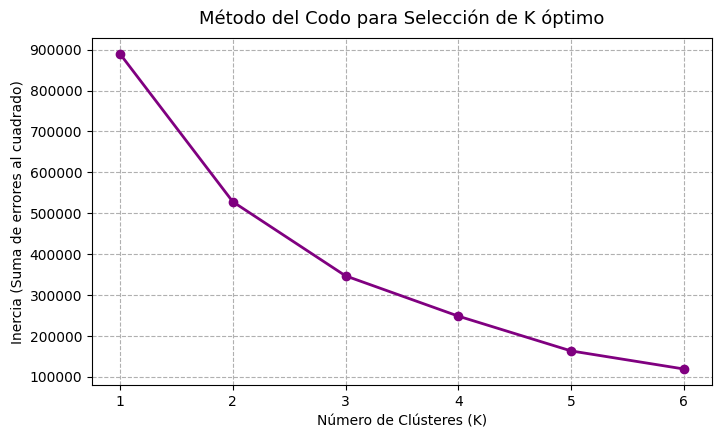

In [6]:
import sys
import os
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.Clustering import Clustering

# Instanciar objeto
cluster_tool = Clustering(file_path="../data/COVID19MEXICO.csv", random_state=42)
cluster_tool.load_and_scale()

# 1. Graficar el método del Codo para justificar la elección de K
inercias = cluster_tool.calculate_elbow(max_k=6)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 7), inercias, marker='o', color='purple', linewidth=2)
plt.title("Método del Codo para Selección de K óptimo", fontsize=13, pad=10)
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Inercia (Suma de errores al cuadrado)")
plt.grid(True, linestyle='--')
plt.show()

La gráfica morada muestra con total claridad cómo va cayendo la línea a medida que aumentamos el número de grupos. El quiebre o "codo" más importante de la estructura ocurre exactamente en **$K = 3$**. A partir de ahí, la curva se aplana y añadir más grupos no aporta un beneficio matemático real. Esto justifica científicamente que dividir la población en 3 perfiles es la decisión más óptima y estable.

### Paso 2: Análisis Estadístico e Interpretación de los Clústeres Reales
Se entrenó el algoritmo K-Means fijando el modelo en 3 clústeres y usando una semilla fija (`random_state=42`) para asegurar que el experimento sea $100\%$ reproducible en Fedora. Al terminar, el algoritmo etiquetó a cada paciente en su grupo correspondiente y se calcularon los promedios reales de cada variable para entender las características de cada sector descubierto.

In [7]:
# 2. Entrenamos el modelo con K=3 clústeres según la justificación visual
df_resultado = cluster_tool.train_kmeans(n_clusters=3)
tabla_perfiles = cluster_tool.get_profiles()

print("\n================ TABLA DE PERFILES POR CLÚSTER ================")
print(tabla_perfiles.round(3))


================ TABLA DE PERFILES POR CLÚSTER ================
           EDAD  DIABETES  HIPERTENSION  OBESIDAD  Tamaño_Grupo
CLUSTER                                                        
0        64.017     0.626         0.752       0.0         38469
1        27.180     0.001         0.001       0.0        169223
2        50.642     0.335         0.420       1.0         14687


**Interpretación de los 3 clusters:**

* **CLUSTER 0 — "Adultos Mayores con Comorbilidades Médicas" (38,469 casos):** Este grupo concentra a la población de la tercera edad, con un promedio de **64 años**. Es un sector críticamente vulnerable, ya que presenta tasas alarmantes de enfermedades: el $75.2\%$ padece Hipertensión y el $62.6\%$ sufre de Diabetes. Ninguno de ellos registra Obesidad (0.00\%).
  
* **CLUSTER 1 — "Población Joven Saludable" (169,223 casos):** Es el grupo más grande de todo el estudio. Está compuesto por jóvenes con un promedio de **27 años** y con tasas prácticamente del $0\%$ en Diabetes, Hipertensión u Obesidad. Representa el sector de la población con la salud basal más estable.
  
* **CLUSTER 2 — "Adultos de Mediana Edad con Obesidad Pura" (14,687 casos):** Este perfil agrupa a adultos maduros con un promedio de **50.6 años**. Lo interesante de este grupo es que el $100\%$ de sus miembros padece Obesidad, pero registran tasas bajas o moderadas de Diabetes ($33.5\%$) e Hipertensión ($42.0\%$). Permite aislar el impacto del sobrepeso en la edad madura.

Mientras que los jóvenes del Clúster 1 se mantendrán mayormente como pacientes ambulatorios, los adultos mayores del Clúster 0 representan el foco rojo de hospitalización que el modelo supervisado debe aprender a proteger.